# Quantum simulation of KdV

Team: Andrei Poliakov, Kyro Jeremy Gibling, Nadav Carmel, Pak Tik, Sahil Ugale

$$
\partial_t u + u\,\partial_x u + \delta\,\partial_{xxx} u = 0, \qquad u(0,x)=u_0(x),
$$

periodic BC on $[0,1]$, same Carleman + implicit Euler + QSVT pathway as the Burgers notebook
(A. Setty, J. Phys. A 59, 185303 (2026)).

KdV's dispersion term is skew-symmetric, unlike Burgers' dissipative diffusion, so Carleman's usual
convergence guarantees (Liu et al., PNAS 118, e2026805118 (2021)) don't automatically transfer. A
classical convergence study (`kdv_convergence_study.py`) found: at the challenge's literal
parameters ($u_0=\cos(4\pi x)$, $\delta=0.05$) dispersion swamps convection and Carleman order
barely matters; scaling $\delta$ down to a linear/nonlinear ratio of ~3-5 gives genuine, monotonic
convergence; pushing further makes the truncation series stop converging, and eventually makes even
the exact ODE blow up. $N=5$, $N_T=2$, $\delta=0.02$ below sits in that convergent window.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)
from scipy.interpolate import RectBivariateSpline

from kdv import KdV_Carlemann, get_implicit_solver_qsvt_lcu
from burgers import compute_inverse_qsvt_angles
import resource_estimation as res_est


## Plot style

Same as the Burgers notebook: classical reference gray dashed, Dense QSVT blue, Pauli-LCU orange.


In [2]:
CLASSICAL_COLOR = "#52514e"
DENSE_COLOR = "#2a78d6"
LCU_COLOR = "#eb6834"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
    "font.size": 11,
})


## 1. Carleman linearization (periodic, no forcing)

Same construction as Burgers, but no $F_0$ term (periodic BC, no external forcing, homogeneous
system) and $F_1$ is dispersion instead of diffusion. Same QSVT toolkit (`burgers.py`, `lcu.py`),
only the classical PDE data (`kdv.py`) differs.

## 2. Phase angles

Same `kappa=8` sequence as Burgers.


In [3]:
kappa = 8
phi_qsvt, s = compute_inverse_qsvt_angles(kappa, tolerance=1e-5)
len(phi_qsvt)


b=280, j0=51
[PolyOneOverX] minimum [-10.69067105] is at [-0.06701114]: normalizing
[PolyOneOverX] bounding to 0.9


560

## 3. Problem setup and resource estimates

$u_0=\cos(4\pi x)$, $\delta=0.02$ (the convergent window found above). Same $N=5$, $N_T=2$ as the
Burgers notebook for a direct resource comparison.


In [4]:
N = 5
N_T = 2
delta = 0.02
total_time = 0.3
dt = 0.1

kdv = KdV_Carlemann(N, N_T, total_time, delta, dt, ic="cos")
x, dx = kdv.get_x_dx()

A_desired = kdv.get_I_m_Adt()
print(f"Shape of A : {A_desired.shape}")


Shape of A : (30, 30)


In [5]:
M, Dim, padded_dim = res_est._carleman_matrix_kdv(N=N, N_T=N_T, total_time=total_time, delta=delta, dt=dt)
n_wires_dense = int(np.ceil(np.log2(M.shape[0]))) + 1
sigma_min = np.min(np.linalg.svd(M, compute_uv=False))

dense_stats = res_est.dense_layer_stats(M, n_wires_dense)
lcu_stats = res_est.lcu_layer_stats(M)
dense_stats["kappa_eff"] = dense_stats["norm"] / sigma_min
lcu_stats["kappa_eff"] = lcu_stats["norm"] / sigma_min

dense_proj = res_est.projector_layer_stats(n_wires_dense, n_ancilla=1)
lcu_proj = res_est.projector_layer_stats(lcu_stats["n_wires"], n_ancilla=lcu_stats["ancilla_qubits"])

n_angles = len(phi_qsvt)
dense_total = res_est.extrapolate_total(dense_stats, dense_proj, n_angles)
lcu_total = res_est.extrapolate_total(lcu_stats, lcu_proj, n_angles)

print(f"Carleman system: N={N}, N_T={N_T} -> Dim={Dim}, padded to {padded_dim}\n")
print(f"{'':14s}{'qubits':>8s}{'alpha':>10s}{'kappa_eff':>11s}{'gates (full circuit)':>24s}{'cx':>16s}{'depth':>16s}")
for name, layer, total in [("Dense", dense_stats, dense_total), ("Pauli-LCU", lcu_stats, lcu_total)]:
    print(f"{name:14s}{total['qubits']:>8d}{layer['norm']:>10.3f}{layer['kappa_eff']:>11.2f}"
          f"{total['gate_count']:>24,d}{total['two_qubit_gates']:>16,d}{total['depth']:>16,d}")


Carleman system: N=5, N_T=2 -> Dim=30, padded to 32

                qubits     alpha  kappa_eff    gates (full circuit)              cx           depth
Dense                6     3.312       3.95               2,605,500         996,697       1,962,091
Pauli-LCU           15     9.859      11.76           2,689,711,074   1,260,998,234   2,016,039,795


**Note on $\kappa_\mathrm{eff}$:** dense encoding's effective condition number ($\approx 4$)
fits comfortably in `kappa=8`'s range; Pauli-LCU's ($\approx 12$) doesn't, since its normalization
$\alpha=\sum_k|c_k|$ is a looser bound. Section 7 shows Pauli-LCU tracking the reference slightly
less tightly as a result -- expected, not a bug. A larger `kappa` would close the gap at the cost
of a longer phase-angle sequence (kept at 8 here to keep the LCU cell runnable in minutes).


## 4. Dense QSVT solver


In [6]:
y_store, RMSE_list, p_success_list = kdv.get_implicit_solver_qsvt(phi_qsvt, s)


Time step 1/3


Time step 2/3


Time step 3/3


## 5. Pauli-LCU solver


In [7]:
y_store_lcu, RMSE_list_lcu, p_success_list_lcu = get_implicit_solver_qsvt_lcu(kdv, phi_qsvt, s)


Time step 1/3


Time step 2/3


Time step 3/3


## 6. Classical reference

Exact, untruncated nonlinear ODE (RK45) -- isolates Carleman truncation and QSVT/LCU error from
spatial-discretization error.


In [8]:
y_ideal, rmse_ideal = kdv.get_implicit_solver()


## 7. Results

### 7.1 Space-time evolution

KdV's dispersion spreads and oscillates the profile, unlike Burgers' steepening.


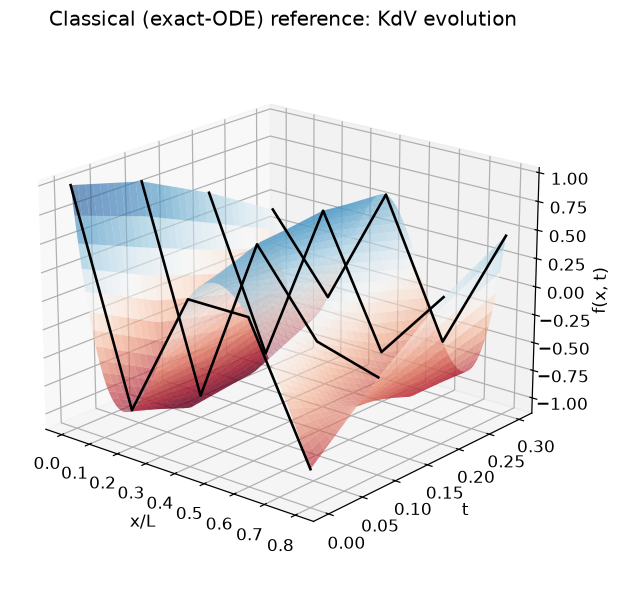

In [9]:
def carpet_plot(ax, x, t, U, ridge_specs, surface_alpha=0.6, elev=20, azim=-50):
    """3D carpet plot (see the Burgers
    notebook for the full docstring); identical implementation, reused here."""
    x_fine = np.linspace(x.min(), x.max(), 150)
    t_fine = np.linspace(t.min(), t.max(), 60)
    spline = RectBivariateSpline(t, x, U, kx=1, ky=3)
    U_fine = spline(t_fine, x_fine)
    X, T = np.meshgrid(x_fine, t_fine)

    vmax = np.max(np.abs(U))
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    ax.plot_surface(X, T, U_fine, cmap="RdBu", norm=norm, linewidth=0,
                     antialiased=True, alpha=surface_alpha, rstride=2, cstride=2)

    for U_vals, color, ls, label in ridge_specs:
        for i, ti in enumerate(t):
            ax.plot(x, np.full_like(x, ti), U_vals[i], color=color, lw=1.7, ls=ls,
                     label=label if (label and i == 0) else None)

    ax.set_xlabel("x/L")
    ax.set_ylabel("t")
    ax.set_zlabel("f(x, t)")
    ax.view_init(elev=elev, azim=azim)


timesteps = np.arange(len(y_ideal)) * dt
u_grid = np.array(y_ideal)  # shape (n_timesteps+1, N)

fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(projection="3d")
carpet_plot(ax, x, timesteps, u_grid, [(u_grid, "black", "-", None)])
ax.set_title("Classical (exact-ODE) reference: KdV evolution")
fig.tight_layout()


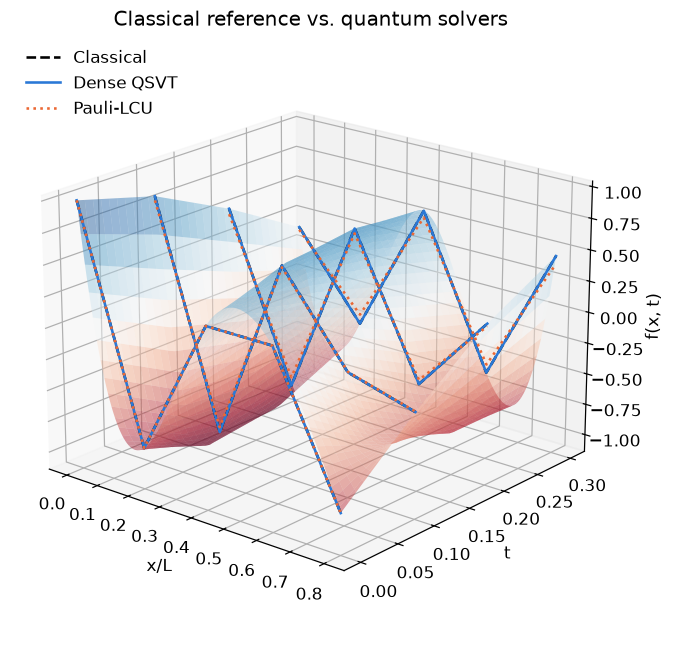

In [10]:
fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(projection="3d")
carpet_plot(
    ax, x, timesteps, u_grid,
    [
        (u_grid, "black", "--", "Classical"),
        (np.array(y_store), DENSE_COLOR, "-", "Dense QSVT"),
        (np.array(y_store_lcu), LCU_COLOR, ":", "Pauli-LCU"),
    ],
    surface_alpha=0.45,
)
ax.legend(loc="upper left", frameon=False)
ax.set_title("Classical reference vs. quantum solvers")
fig.tight_layout()


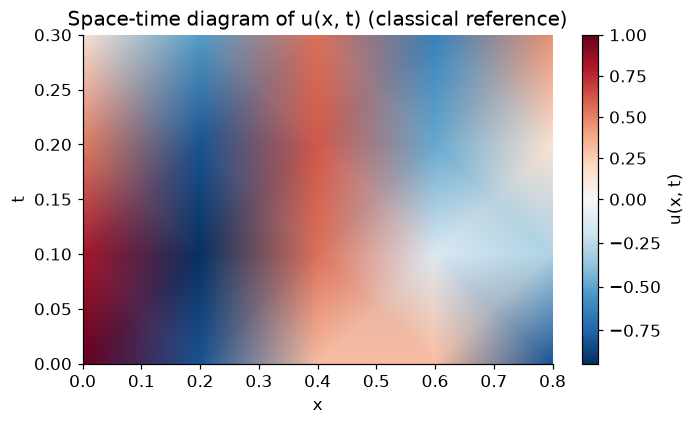

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
norm = TwoSlopeNorm(vcenter=0.0, vmin=u_grid.min(), vmax=u_grid.max())
im = ax.pcolormesh(x, timesteps, u_grid, shading="gouraud", cmap="RdBu_r", norm=norm)
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Space-time diagram of u(x, t) (classical reference)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("u(x, t)")
fig.tight_layout()


### 7.2 Classical vs. quantum, timestep by timestep


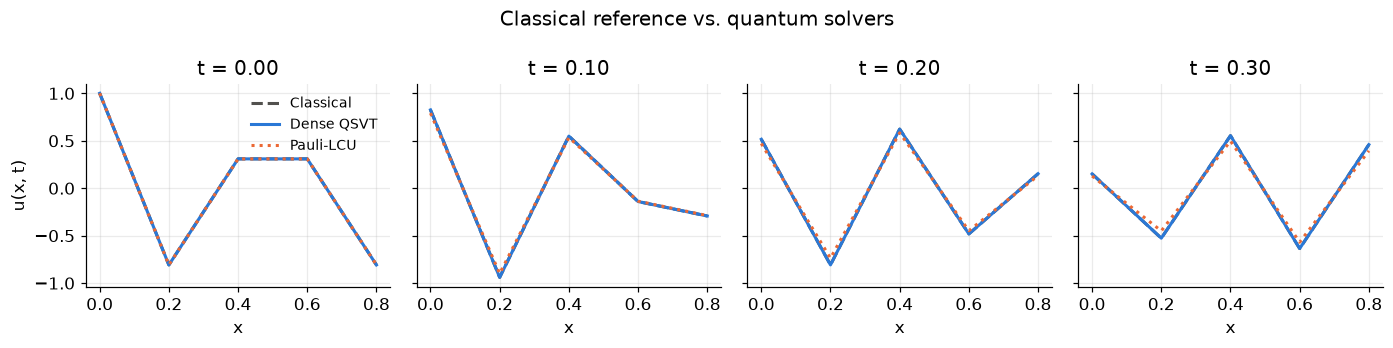

In [12]:
n_panels = len(y_ideal)
fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 3.2), sharey=True)
for i, ax in enumerate(axes):
    ax.plot(x, y_ideal[i], color=CLASSICAL_COLOR, lw=2, ls="--", label="Classical")
    ax.plot(x, y_store[i], color=DENSE_COLOR, lw=2, label="Dense QSVT")
    ax.plot(x, y_store_lcu[i], color=LCU_COLOR, lw=2, ls=":", label="Pauli-LCU")
    ax.set_title(f"t = {timesteps[i]:.2f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x, t)")
axes[0].legend(frameon=False, loc="upper right", fontsize=9)
fig.suptitle("Classical reference vs. quantum solvers")
fig.tight_layout()


### 7.3 Accuracy and success probability


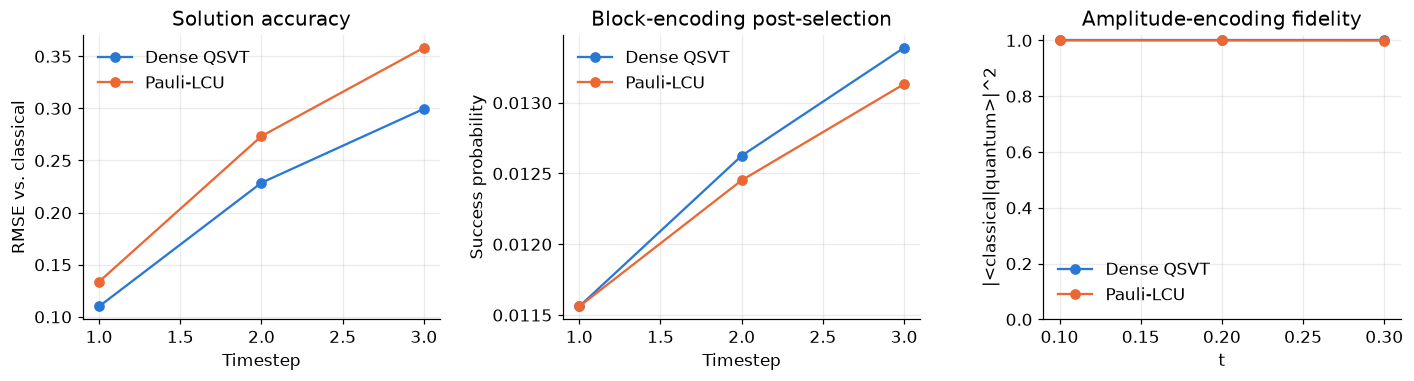

In [13]:
def fidelity(u_ref, u_test):
    u_ref = np.asarray(u_ref)
    u_test = np.asarray(u_test)
    nr, nt = np.linalg.norm(u_ref), np.linalg.norm(u_test)
    if nr == 0 or nt == 0:
        return np.nan
    return (np.dot(u_ref, u_test) / (nr * nt)) ** 2


fidelity_dense = [fidelity(y_ideal[i], y_store[i]) for i in range(1, len(y_ideal))]
fidelity_lcu = [fidelity(y_ideal[i], y_store_lcu[i]) for i in range(1, len(y_ideal))]
step_index = np.arange(1, len(RMSE_list) + 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

ax = axes[0]
ax.plot(step_index, RMSE_list, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(step_index, RMSE_list_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("Timestep")
ax.set_ylabel("RMSE vs. classical")
ax.set_title("Solution accuracy")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(step_index, p_success_list, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(step_index, p_success_list_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("Timestep")
ax.set_ylabel("Success probability")
ax.set_title("Block-encoding post-selection")
ax.legend(frameon=False)

ax = axes[2]
ax.plot(timesteps[1:], fidelity_dense, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(timesteps[1:], fidelity_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("t")
ax.set_ylabel("|<classical|quantum>|^2")
ax.set_title("Amplitude-encoding fidelity")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower left")

fig.tight_layout()


### 7.4 Resource comparison


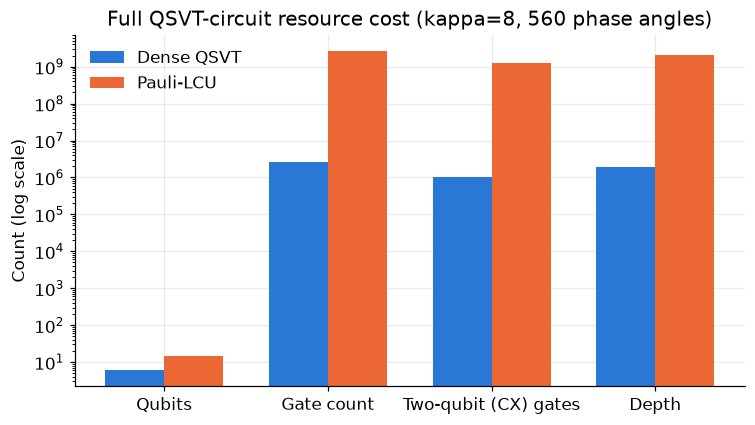

In [14]:
metrics = ["qubits", "gate_count", "two_qubit_gates", "depth"]
metric_labels = ["Qubits", "Gate count", "Two-qubit (CX) gates", "Depth"]
dense_vals = [dense_total[m] for m in metrics]
lcu_vals = [lcu_total[m] for m in metrics]

fig, ax = plt.subplots(figsize=(7, 4))
xpos = np.arange(len(metrics))
width = 0.36
ax.bar(xpos - width / 2, dense_vals, width, color=DENSE_COLOR, label="Dense QSVT")
ax.bar(xpos + width / 2, lcu_vals, width, color=LCU_COLOR, label="Pauli-LCU")
ax.set_yscale("log")
ax.set_xticks(xpos)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Full QSVT-circuit resource cost (kappa={kappa}, {n_angles} phase angles)")
ax.legend(frameon=False)
fig.tight_layout()
